<a href="https://colab.research.google.com/github/BuKarData/TrafficSignsRecognition/blob/jupyternotebook/Traffic_Sign_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kapon00","key":"e1d7ce333dc4cf3c4cb53eba170d7f48"}'}

In [4]:
!pip install -q kaggle

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!mkdir trafficSignDataset

In [9]:
%cd trafficSignDataset

/content/trafficSignDataset


In [10]:
!kaggle datasets list -s gtsrb-german-traffic-sign

ref                                                                title                                               size  lastUpdated          downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
meowmeowmeowmeowmeow/gtsrb-german-traffic-sign                     GTSRB - German Traffic Sign Recognition Benchmark  612MB  2018-11-25 18:12:34         132422       1191  0.8235294        
valentynsichkar/traffic-signs-preprocessed                         Traffic Signs Preprocessed                           4GB  2019-08-31 18:22:11          16566        303  1.0              
harbhajansingh21/german-traffic-sign-dataset                       German Traffic Sign Dataset                        118MB  2023-07-11 04:21:24           1907         33  1.0              
ibrahimkaratas/gtsrb-german-traffic-sign-recogniti

In [11]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
 96% 590M/612M [00:06<00:00, 203MB/s]
100% 612M/612M [00:06<00:00, 102MB/s]


In [12]:
%cd ..

/content


In [13]:
!unzip trafficSignDataset/gtsrb-german-traffic-sign.zip -d trafficSignDataset
!rm trafficSignDataset/gtsrb-german-traffic-sign.zip
!rm -rf trafficSignDataset/Meta
!rm -rf trafficSignDataset/meta
!rm -rf trafficSignDataset/test
!rm -rf trafficSignDataset/train
!rm trafficSignDataset/Meta.csv

Streaming output truncated to the last 5000 lines.
  inflating: trafficSignDataset/train/5/00005_00053_00010.png  
  inflating: trafficSignDataset/train/5/00005_00053_00011.png  
  inflating: trafficSignDataset/train/5/00005_00053_00012.png  
  inflating: trafficSignDataset/train/5/00005_00053_00013.png  
  inflating: trafficSignDataset/train/5/00005_00053_00014.png  
  inflating: trafficSignDataset/train/5/00005_00053_00015.png  
  inflating: trafficSignDataset/train/5/00005_00053_00016.png  
  inflating: trafficSignDataset/train/5/00005_00053_00017.png  
  inflating: trafficSignDataset/train/5/00005_00053_00018.png  
  inflating: trafficSignDataset/train/5/00005_00053_00019.png  
  inflating: trafficSignDataset/train/5/00005_00053_00020.png  
  inflating: trafficSignDataset/train/5/00005_00053_00021.png  
  inflating: trafficSignDataset/train/5/00005_00053_00022.png  
  inflating: trafficSignDataset/train/5/00005_00053_00023.png  
  inflating: trafficSignDataset/train/5/00005_00053_0

In [14]:
#importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as imread
import seaborn as sns
import random
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

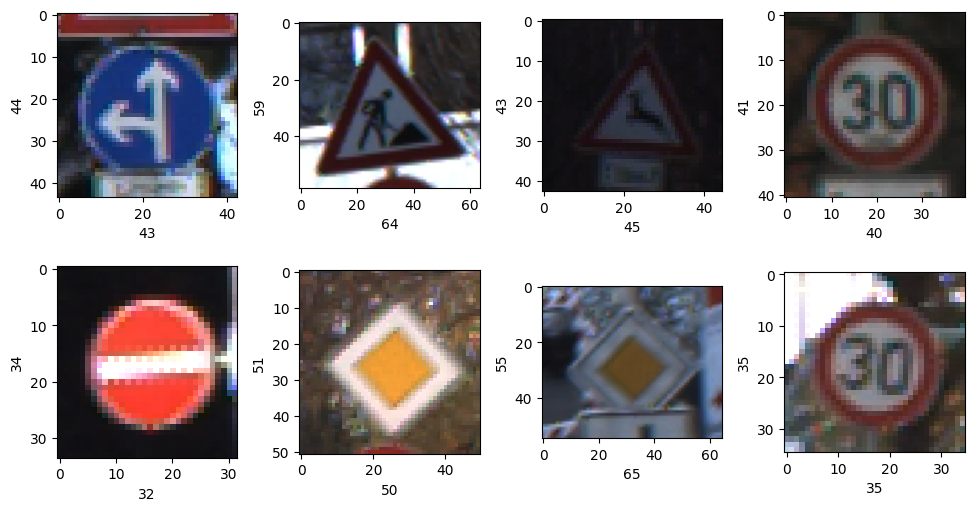

In [21]:
#Visualizing data
plt.figure(figsize=(10, 10))
path = "trafficSignDataset/Test"
for i in range(1,9):
  plt.subplot(4,4,i)
  plt.tight_layout()
  rand_img = imread.imread(path + '/' + random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize = 10)
  plt.ylabel(rand_img.shape[0], fontsize = 10)

In [29]:
#Mean of dimensions
dim1 = []
dim2 = []

for i in range(0,43):
  labels = 'trafficSignDataset/Train/' + '/{0}'.format(i)
  image_path = os.listdir(labels)
  for j in image_path:
    img = imread.imread(labels + '/' + j)
    dim1.append(img.shape[0])
    dim2.append(img.shape[1])

In [31]:
#printing mean dimension
print("Dimension 1 mean: ", np.mean(dim1), "Dimension 2 mean: ", np.mean(dim2))

Dimension 1 mean:  50.328929582493814 Dimension 2 mean:  50.83587951745773


In [32]:
images = []
label_id = []

#reshaping pictures
for i in range(43):
  labels = 'trafficSignDataset/Train/' + '/{0}'.format(i)
  image_path = os.listdir(labels)
  for j in image_path:
    img = Image.open(labels+ '/' + j)
    img = img.resize((50,50))
    img = np.array(img)
    images.append(img)
    label_id.append(i)

In [33]:
images = np.array(images)
#normalization
images = images/255

In [35]:
label_id = np.array(label_id)
label_id.shape
images.shape

(39209, 50, 50, 3)

In [36]:
label_counts = pd.DataFrame(label_id).value_counts()
label_counts.head()

,count
0,
2,2250
1,2220
13,2160
12,2100
38,2070


In [37]:
#splitting data
X_train, x_val, Y_train, y_val = train_test_split(images, label_id, test_size=0.2, random_state=42)

In [38]:
y_train_cat = to_categorical(Y_train)
y_val_cat = to_categorical(y_val)

In [39]:
#building model

model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=X_train.shape[1:], padding = 'same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(loss='sparse_categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 50, 50, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 23, 23, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7744)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         991,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,035,627 (3.95 MB)

 Trainable params: 1,035,627 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.fit(X_train, Y_train, batch_size=128, epochs=5, validation_data=(x_val, y_val), verbose = 2)

Epoch 1/5
246/246 - 249s - 1s/step - accuracy: 0.5179 - loss: 1.5431 - val_accuracy: 0.8097 - val_loss: 0.7702
Epoch 2/5
246/246 - 265s - 1s/step - accuracy: 0.6858 - loss: 0.9676 - val_accuracy: 0.9077 - val_loss: 0.4140
Epoch 3/5
246/246 - 294s - 1s/step - accuracy: 0.7556 - loss: 0.7388 - val_accuracy: 0.9473 - val_loss: 0.2887
Epoch 4/5
246/246 - 256s - 1s/step - accuracy: 0.7964 - loss: 0.6102 - val_accuracy: 0.9633 - val_loss: 0.2057
Epoch 5/5
246/246 - 236s - 958ms/step - accuracy: 0.8232 - loss: 0.5318 - val_accuracy: 0.9717 - val_loss: 0.1633


<Axes: >

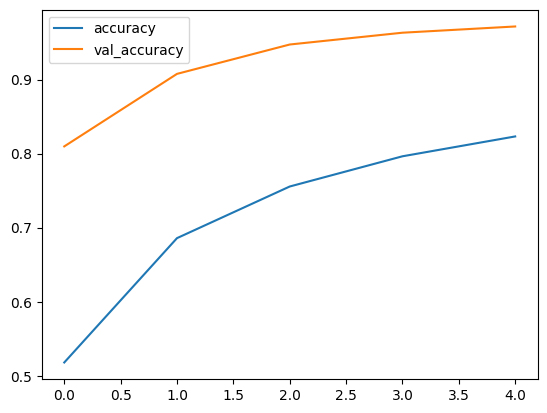

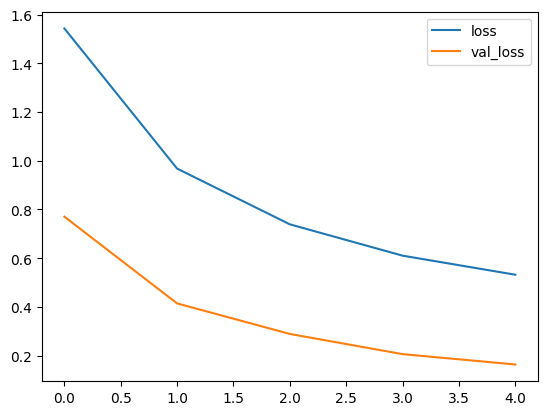

In [45]:
model_evaluation = pd.DataFrame(model.history.history)
model_evaluation[['accuracy','val_accuracy']].plot()
model_evaluation[['loss','val_loss']].plot()

In [46]:
test_path  = 'trafficSignDataset/Test'
!rm trafficSignDataset/Test/GT-final_test.csv


In [47]:
#defining scaling function
def scaling(test_images, test_path):
  images = []

  image_path = test_images

  for i in image_path:
    img = Image.open(test_path + '/' + i)
    img = img.resize((50,50))
    img = np.array(img)
    images.append(img)

  images = np.array(images)
  images = images/255 #normalization
  return images

In [48]:
test_images = scaling(sorted(os.listdir(test_path)), test_path)

In [49]:
test = pd.read_csv('trafficSignDataset/Test.csv')
y_test = test['ClassId'].values
y_test

array([16,  1, 38, ...,  6,  7, 10])

In [51]:
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_pred_classes

395/395 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step


array([16,  1, 38, ...,  5,  7, 10])

In [52]:
all_labels = []
for i in range(43):
  all_labels.append(i)

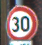

In [53]:
image = Image.open(test_path + '/00001.png')
image

In [56]:
print('Original label: ', all_labels[y_test[1]])
print('Predicted label: ', all_labels[y_pred_classes[1]])


Original label:  1
Predicted label:  1
